In [15]:
from pathlib import Path
import sys

from experimento_aa import run_aa_experiment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: c:\Users\adanm\Code\tesis


In [3]:
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from experimento_aa import (
    prepare_aa_data,
    train_aa_and_reconstruct,
    calculate_aa_metrics,
)

Using NumPy backend


In [4]:
DATASET_REFERENCIA = "medianas_fase_50"
NORMALIZACION_REFERENCIA = "minmax"
INICIALIZACION_AA = "pca_convex_hull_furthest_sum"

VALORES_K = range(2, 11)

N_ESTRELLAS_SUBMUESTRA = 5000
SEMILLA_MUESTREO = 42
SEMILLA_MODELO = 0

In [5]:
X_train, X_val, metadata_train, metadata_val = prepare_aa_data(
    dataset=DATASET_REFERENCIA,
    normalizacion=NORMALIZACION_REFERENCIA,
)

print(f"Entrenamiento completo: {X_train.shape}")
print(f"Validación completa: {X_val.shape}")
print(
    "Estrellas físicas en entrenamiento: "
    f"{metadata_train['star_id_base'].nunique():,}"
)

Entrenamiento completo: (61466, 50)
Validación completa: (20576, 50)
Estrellas físicas en entrenamiento: 42,042


In [6]:
from sklearn.model_selection import train_test_split


subtipos_por_estrella = (
    metadata_train[
        ["star_id_base", "subtipo_rrlyrae"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

estrellas_submuestra, _ = train_test_split(
    subtipos_por_estrella,
    train_size=N_ESTRELLAS_SUBMUESTRA,
    random_state=SEMILLA_MUESTREO,
    stratify=subtipos_por_estrella["subtipo_rrlyrae"],
)

ids_submuestra = set(
    estrellas_submuestra["star_id_base"]
)

mascara_submuestra = (
    metadata_train["star_id_base"]
    .isin(ids_submuestra)
    .to_numpy()
)

X_train_submuestra = X_train[mascara_submuestra]

metadata_train_submuestra = (
    metadata_train.loc[mascara_submuestra]
    .reset_index(drop=True)
)

print(
    "Estrellas físicas seleccionadas: "
    f"{metadata_train_submuestra['star_id_base'].nunique():,}"
)
print(f"Curvas seleccionadas: {X_train_submuestra.shape[0]:,}")
print("\nEstrellas por subtipo:")
print(
    estrellas_submuestra[
        "subtipo_rrlyrae"
    ].value_counts()
)

Estrellas físicas seleccionadas: 5,000
Curvas seleccionadas: 7,313

Estrellas por subtipo:
subtipo_rrlyrae
RRab    3535
RRc     1299
RRd      166
Name: count, dtype: int64


In [7]:
K_PILOTO = 2

resultado_piloto = train_aa_and_reconstruct(
    X_train=X_train_submuestra,
    X_val=X_val,
    k=K_PILOTO,
    seed=SEMILLA_MODELO,
    inicializacion=INICIALIZACION_AA,
)

metricas_piloto = calculate_aa_metrics(
    X_train=X_train_submuestra,
    X_val=X_val,
    metadata_val=metadata_val,
    resultado_modelo=resultado_piloto,
)

print(f"K: {K_PILOTO}")
print(
    "Tiempo de entrenamiento: "
    f"{resultado_piloto['tiempo_entrenamiento']:.3f} segundos"
)
print(f"Iteraciones: {resultado_piloto['modelo'].n_iter_}")
print(f"MSE validación: {metricas_piloto['mse_val']:.6f}")
print(f"RSS validación: {metricas_piloto['rss_val']:.6f}")
print(f"Silhouette: {metricas_piloto['silhouette_val']:.6f}")
print(
    "Davies-Bouldin: "
    f"{metricas_piloto['davies_bouldin_val']:.6f}"
)
print(f"Pureza: {metricas_piloto['purity_val']:.6f}")
print(f"AMI: {metricas_piloto['ami_val']:.6f}")

K: 2
Tiempo de entrenamiento: 6.356 segundos
Iteraciones: 23
MSE validación: 0.008704
RSS validación: 8954.375085
Silhouette: 0.479474
Davies-Bouldin: 0.888886
Pureza: 0.914755
AMI: 0.614444


In [8]:
resultados_k = [
    {
        "K": K_PILOTO,
        "tiempo_entrenamiento_segundos": (
            resultado_piloto["tiempo_entrenamiento"]
        ),
        "iteraciones_reales": (
            resultado_piloto["modelo"].n_iter_
        ),
        **metricas_piloto,
    }
]


for k in VALORES_K:
    if k == K_PILOTO:
        continue

    print(f"\nEjecutando K={k}...")

    resultado_k = train_aa_and_reconstruct(
        X_train=X_train_submuestra,
        X_val=X_val,
        k=k,
        seed=SEMILLA_MODELO,
        inicializacion=INICIALIZACION_AA,
    )

    metricas_k = calculate_aa_metrics(
        X_train=X_train_submuestra,
        X_val=X_val,
        metadata_val=metadata_val,
        resultado_modelo=resultado_k,
    )

    resultados_k.append(
        {
            "K": k,
            "tiempo_entrenamiento_segundos": (
                resultado_k["tiempo_entrenamiento"]
            ),
            "iteraciones_reales": (
                resultado_k["modelo"].n_iter_
            ),
            **metricas_k,
        }
    )

    print(
        f"K={k} completado | "
        f"tiempo={resultado_k['tiempo_entrenamiento']:.3f} s | "
        f"MSE val={metricas_k['mse_val']:.6f} | "
        f"silhouette={metricas_k['silhouette_val']:.6f}"
    )


df_resultados_k = (
    pd.DataFrame(resultados_k)
    .sort_values("K")
    .reset_index(drop=True)
)

display(df_resultados_k)


Ejecutando K=3...
K=3 completado | tiempo=8.267 s | MSE val=0.005461 | silhouette=0.356642

Ejecutando K=4...
K=4 completado | tiempo=16.693 s | MSE val=0.004558 | silhouette=0.291034

Ejecutando K=5...
K=5 completado | tiempo=19.359 s | MSE val=0.004276 | silhouette=0.275879

Ejecutando K=6...
K=6 completado | tiempo=62.417 s | MSE val=0.003749 | silhouette=0.206165

Ejecutando K=7...
K=7 completado | tiempo=49.312 s | MSE val=0.003318 | silhouette=0.245848

Ejecutando K=8...
K=8 completado | tiempo=22.630 s | MSE val=0.003217 | silhouette=0.241188

Ejecutando K=9...
K=9 completado | tiempo=124.019 s | MSE val=0.003110 | silhouette=0.226557

Ejecutando K=10...
K=10 completado | tiempo=67.471 s | MSE val=0.003086 | silhouette=0.225234


,K,tiempo_entrenamiento_segundos,iteraciones_reales,mse_train,rss_train,mse_val,rss_val,purity_val,davies_bouldin_val,silhouette_val,ami_val
0,2,6.356285,23,0.008710,3184.716810,0.008704,8954.375085,0.914755,0.888886,0.479474,0.614444
1,3,8.267177,36,0.005411,1978.550278,0.005461,5618.702001,0.920927,1.101582,0.356642,0.453474
2,4,16.693301,70,0.004539,1659.549987,0.004558,4688.974728,0.917428,1.476542,0.291034,0.418560
3,5,19.359473,82,0.004242,1551.063276,0.004276,4399.108510,0.913151,1.473842,0.275879,0.427618
4,6,62.416786,254,0.003689,1348.852659,0.003749,3856.952456,0.927634,1.546504,0.206165,0.389034
5,7,49.312114,121,0.003238,1183.800364,0.003318,3413.055349,0.933661,1.470091,0.245848,0.379000
6,8,22.629700,52,0.003138,1147.581120,0.003217,3309.498511,0.931425,1.552845,0.241188,0.375305
7,9,124.019457,195,0.003037,1110.440834,0.003110,3199.223738,0.929773,1.646105,0.226557,0.365188
8,10,67.470842,149,0.003010,1100.750581,0.003086,3175.390047,0.930599,1.910496,0.225234,0.365929


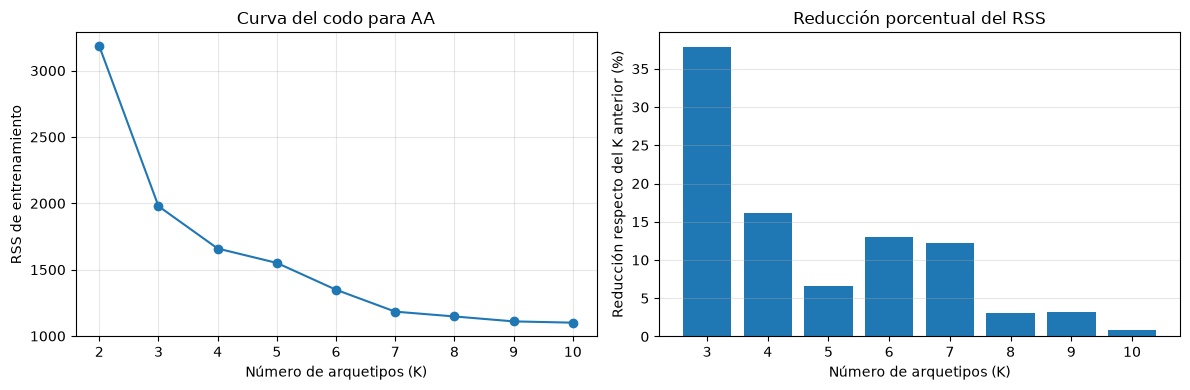

,K,rss_train,reduccion_rss_porcentaje
0,2,3184.716810,NaN
1,3,1978.550278,37.873588
2,4,1659.549987,16.122931
3,5,1551.063276,6.537116
4,6,1348.852659,13.036903
5,7,1183.800364,12.236495
6,8,1147.581120,3.059574
7,9,1110.440834,3.236397
8,10,1100.750581,0.872649


In [9]:
df_resultados_k["reduccion_rss_porcentaje"] = (
    df_resultados_k["rss_train"]
    .shift(1)
    .sub(df_resultados_k["rss_train"])
    .div(df_resultados_k["rss_train"].shift(1))
    .mul(100)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4),
)

axes[0].plot(
    df_resultados_k["K"],
    df_resultados_k["rss_train"],
    marker="o",
)

axes[0].set_title("Curva del codo para AA")
axes[0].set_xlabel("Número de arquetipos (K)")
axes[0].set_ylabel("RSS de entrenamiento")
axes[0].grid(alpha=0.3)

axes[1].bar(
    df_resultados_k["K"],
    df_resultados_k["reduccion_rss_porcentaje"],
)

axes[1].set_title("Reducción porcentual del RSS")
axes[1].set_xlabel("Número de arquetipos (K)")
axes[1].set_ylabel("Reducción respecto del K anterior (%)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

display(
    df_resultados_k[
        [
            "K",
            "rss_train",
            "reduccion_rss_porcentaje",
        ]
    ]
)

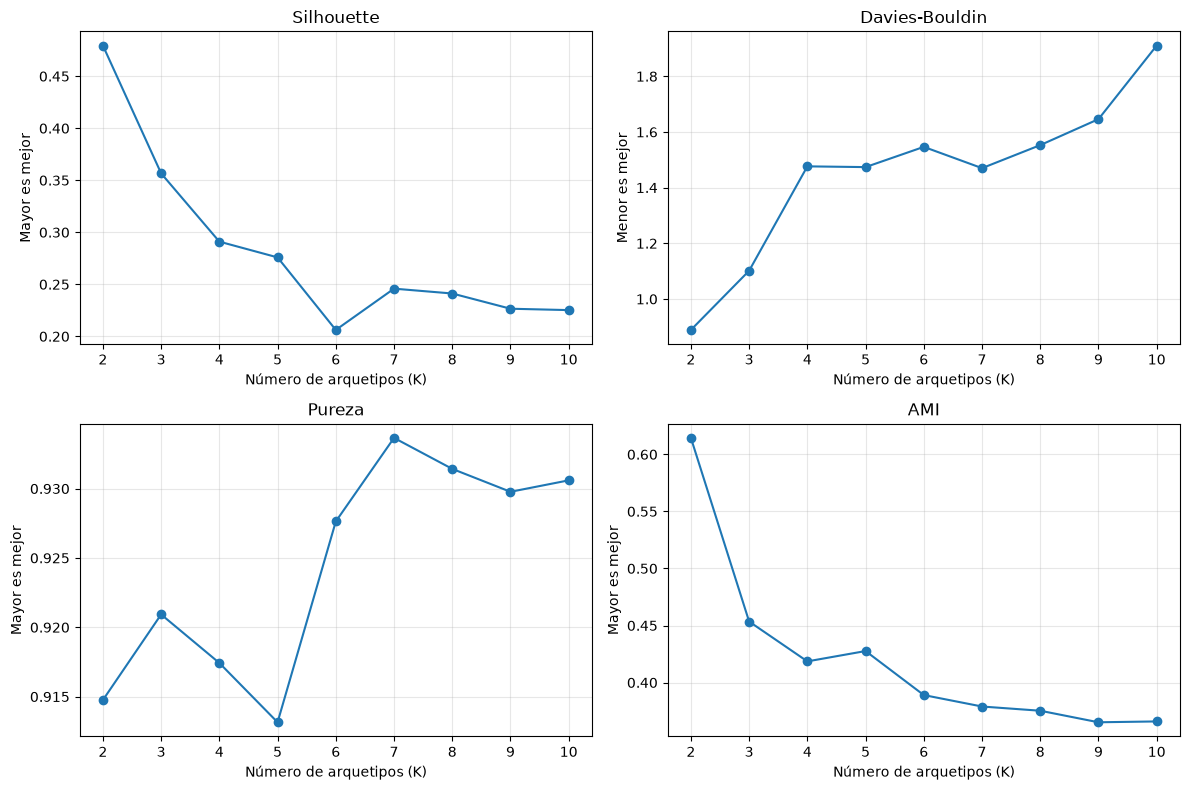

In [10]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8),
)

axes[0, 0].plot(
    df_resultados_k["K"],
    df_resultados_k["silhouette_val"],
    marker="o",
)
axes[0, 0].set_title("Silhouette")
axes[0, 0].set_ylabel("Mayor es mejor")

axes[0, 1].plot(
    df_resultados_k["K"],
    df_resultados_k["davies_bouldin_val"],
    marker="o",
)
axes[0, 1].set_title("Davies-Bouldin")
axes[0, 1].set_ylabel("Menor es mejor")

axes[1, 0].plot(
    df_resultados_k["K"],
    df_resultados_k["purity_val"],
    marker="o",
)
axes[1, 0].set_title("Pureza")
axes[1, 0].set_ylabel("Mayor es mejor")

axes[1, 1].plot(
    df_resultados_k["K"],
    df_resultados_k["ami_val"],
    marker="o",
)
axes[1, 1].set_title("AMI")
axes[1, 1].set_ylabel("Mayor es mejor")

for ax in axes.flat:
    ax.set_xlabel("Número de arquetipos (K)")
    ax.set_xticks(list(VALORES_K))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
VALORES_K_CANDIDATOS = [4, 5, 6, 7]

resultados_candidatos = {}
resumen_arquetipos = []

for k in VALORES_K_CANDIDATOS:

    print(f"Entrenando candidato K={k}...")

    resultado = train_aa_and_reconstruct(
        X_train=X_train_submuestra,
        X_val=X_val,
        k=k,
        seed=SEMILLA_MODELO,
        inicializacion=INICIALIZACION_AA,
    )

    resultados_candidatos[k] = resultado

    arquetipos = resultado["arquetipos_originales"]
    alphas_val = resultado["alphas_val"]
    grupos_val = resultado["grupos_val"]

    conteos = np.bincount(
        grupos_val,
        minlength=k,
    )

    for indice_arquetipo in range(k):

        mascara_grupo = (
            grupos_val == indice_arquetipo
        )

        arquetipo = arquetipos[indice_arquetipo]

        # Variación local circular del arquetipo.
        rugosidad = np.mean(
            np.abs(
                np.roll(arquetipo, -1)
                - 2 * arquetipo
                + np.roll(arquetipo, 1)
            )
        )

        if mascara_grupo.any():
            dominancia_media = (
                alphas_val[
                    mascara_grupo,
                    indice_arquetipo,
                ]
                .mean()
            )
        else:
            dominancia_media = np.nan

        resumen_arquetipos.append(
            {
                "K": k,
                "arquetipo": indice_arquetipo + 1,
                "n_dominante_val": conteos[indice_arquetipo],
                "porcentaje_dominante_val": (
                    conteos[indice_arquetipo]
                    / len(grupos_val)
                    * 100
                ),
                "alpha_promedio_total": (
                    alphas_val[
                        :,
                        indice_arquetipo,
                    ]
                    .mean()
                ),
                "alpha_dominante_medio": dominancia_media,
                "rugosidad": rugosidad,
            }
        )


df_resumen_arquetipos = pd.DataFrame(
    resumen_arquetipos
)

display(df_resumen_arquetipos)

Entrenando candidato K=4...
Entrenando candidato K=5...
Entrenando candidato K=6...
Entrenando candidato K=7...


,K,arquetipo,n_dominante_val,porcentaje_dominante_val,alpha_promedio_total,alpha_dominante_medio,rugosidad
0,4,1,1525,7.411547,0.095787,0.585835,0.050815
1,4,2,4739,23.031687,0.220236,0.630665,0.014445
2,4,3,5539,26.919712,0.296637,0.650367,0.022404
3,4,4,8773,42.637053,0.387340,0.736779,0.017770
4,5,1,5,0.024300,0.027128,0.338019,0.049589
5,5,2,1863,9.054238,0.102624,0.603320,0.044475
6,5,3,5427,26.375389,0.284041,0.647406,0.021385
7,5,4,8609,41.840008,0.372918,0.726783,0.018216
8,5,5,4672,22.706065,0.213290,0.616950,0.014253
9,6,1,5,0.024300,0.023808,0.330986,0.049009


In [18]:
RUTA_REGISTRO = (
    PROJECT_ROOT
    / "resultados"
    / "registro_experimentos.csv"
)

df_registro = pd.read_csv(RUTA_REGISTRO)

ejecuciones_completas = (
    df_registro.loc[
        (df_registro["modelo"] == "archetypal_analysis")
        & (df_registro["dataset"] == "medianas_fase_50")
        & (df_registro["normalizacion"] == "minmax")
        & (
            df_registro["inicializacion"]
            == "pca_convex_hull_furthest_sum"
        )
        & (df_registro["optimizador"] == "nnls")
        & (df_registro["K"].isin([4, 5, 6]))
    ]
    .sort_values(["K", "seed_modelo"])
    .reset_index(drop=True)
)

print("Ejecuciones completas encontradas:")
display(
    ejecuciones_completas[
        [
            "experiment_id",
            "K",
            "seed_modelo",
            "convergio",
            "iteraciones_reales",
        ]
    ]
)


resumen_full = []
detalle_full = []

for _, fila in ejecuciones_completas.iterrows():

    k = int(fila["K"])
    seed = int(fila["seed_modelo"])

    ruta_relativa = Path(
        str(fila["ruta_experimento"])
        .replace("\\", "/")
    )

    carpeta = PROJECT_ROOT / ruta_relativa

    patrones = np.load(
        carpeta / "patrones.npy"
    )

    grupos_val = np.load(
        carpeta / "grupos_val.npy"
    ).astype(int)

    alphas_val = np.load(
        carpeta / "alphas_val.npy"
    )

    conteos = np.bincount(
        grupos_val,
        minlength=k,
    )

    porcentajes = (
        conteos
        / len(grupos_val)
        * 100
    )

    rugosidades = []

    for indice in range(k):

        patron = patrones[indice]

        rugosidad = np.mean(
            np.abs(
                np.roll(patron, -1)
                - 2 * patron
                + np.roll(patron, 1)
            )
        )

        rugosidades.append(rugosidad)

        mascara = grupos_val == indice

        detalle_full.append(
            {
                "K": k,
                "seed_modelo": seed,
                "arquetipo": indice + 1,
                "n_dominante_val": conteos[indice],
                "porcentaje_dominante_val": porcentajes[indice],
                "alpha_promedio_total": (
                    alphas_val[:, indice].mean()
                ),
                "alpha_dominante_medio": (
                    alphas_val[
                        mascara,
                        indice,
                    ].mean()
                    if mascara.any()
                    else np.nan
                ),
                "rugosidad": rugosidad,
            }
        )

    resumen_full.append(
        {
            "K": k,
            "seed_modelo": seed,
            "n_grupo_menor": conteos.min(),
            "porcentaje_grupo_menor": porcentajes.min(),
            "n_arquetipos_menor_1_pct": (
                porcentajes < 1
            ).sum(),
            "rugosidad_maxima": max(rugosidades),
            "convergio": fila["convergio"],
        }
    )


df_resumen_full = pd.DataFrame(
    resumen_full
)

df_detalle_full = pd.DataFrame(
    detalle_full
)

print("\nResumen por ejecución:")
display(df_resumen_full)

print("\nArquetipos con menos del 1 % de las curvas:")
display(
    df_detalle_full.loc[
        df_detalle_full[
            "porcentaje_dominante_val"
        ] < 1
    ]
)

Ejecuciones completas encontradas:


,experiment_id,K,seed_modelo,convergio,iteraciones_reales
0,a72839ea7be92ca5,4,0,True,139
1,130b477559867762,5,0,True,234
2,4dd949ada25b888e,5,1,True,297
3,37dedb2834a007b2,5,2,False,300
4,349e82cdd54799e0,5,3,False,300
5,976409505a67e4f6,5,4,True,204
6,2cfeeb96eca87a5a,6,0,False,300
7,7b2b19e92228364d,6,1,True,216
8,7e10f1ff296d6864,6,2,True,252
9,84e12f8e09d12d32,6,3,True,252



Resumen por ejecución:


,K,seed_modelo,n_grupo_menor,porcentaje_grupo_menor,n_arquetipos_menor_1_pct,rugosidad_maxima,convergio
0,4,0,1639,7.965591,0,0.043829,True
1,5,0,508,2.468896,0,0.041448,True
2,5,1,508,2.468896,0,0.041448,True
3,5,2,509,2.473756,0,0.041420,False
4,5,3,509,2.473756,0,0.041420,False
5,5,4,508,2.468896,0,0.041448,True
6,6,0,7,0.034020,1,0.169774,False
7,6,1,34,0.165241,1,0.159544,True
8,6,2,34,0.165241,1,0.159543,True
9,6,3,34,0.165241,1,0.159543,True



Arquetipos con menos del 1 % de las curvas:


,K,seed_modelo,arquetipo,n_dominante_val,porcentaje_dominante_val,alpha_promedio_total,alpha_dominante_medio,rugosidad
33,6,0,5,7,0.034020,0.031480,0.413165,0.169774
40,6,1,6,34,0.165241,0.050497,0.417740,0.159544
43,6,2,3,34,0.165241,0.050497,0.417740,0.159543
49,6,3,3,34,0.165241,0.050497,0.417740,0.159543
56,6,4,4,34,0.165241,0.050497,0.417740,0.159543


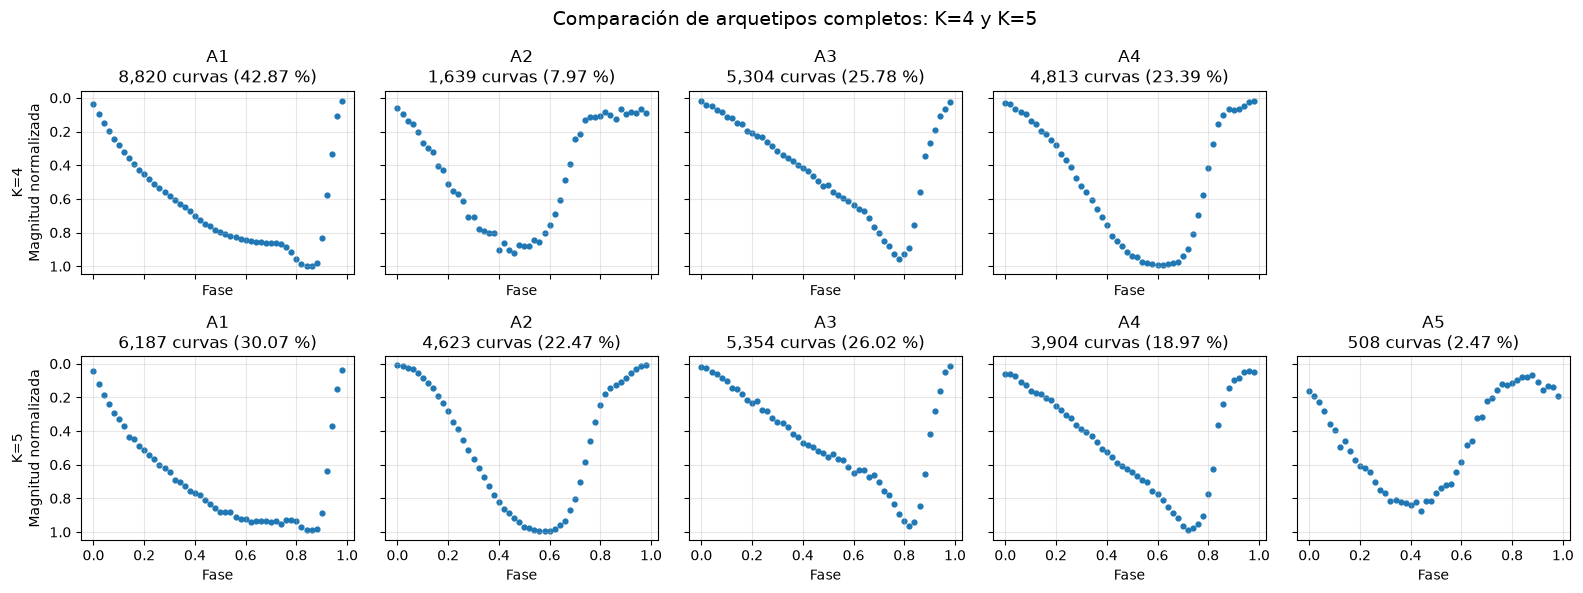

In [19]:
SEMILLA_COMPARACION = 0

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(16, 6),
    sharex=True,
    sharey=True,
)

for fila_grafico, k in enumerate([4, 5]):

    ejecucion = ejecuciones_completas.loc[
        (ejecuciones_completas["K"] == k)
        & (
            ejecuciones_completas["seed_modelo"]
            == SEMILLA_COMPARACION
        )
    ].iloc[0]

    ruta_relativa = Path(
        str(ejecucion["ruta_experimento"])
        .replace("\\", "/")
    )

    carpeta = PROJECT_ROOT / ruta_relativa

    patrones = np.load(
        carpeta / "patrones.npy"
    )

    grupos_val = np.load(
        carpeta / "grupos_val.npy"
    ).astype(int)

    conteos = np.bincount(
        grupos_val,
        minlength=k,
    )

    porcentajes = (
        conteos
        / len(grupos_val)
        * 100
    )

    fases = np.linspace(
        0,
        1,
        patrones.shape[1],
        endpoint=False,
    )

    for indice in range(5):

        ax = axes[fila_grafico, indice]

        if indice < k:

            ax.scatter(
                fases,
                patrones[indice],
                s=12,
            )

            ax.set_title(
                f"A{indice + 1}\n"
                f"{conteos[indice]:,} curvas "
                f"({porcentajes[indice]:.2f} %)"
            )

            ax.grid(alpha=0.3)

        else:
            ax.axis("off")

        if indice == 0:
            ax.set_ylabel(
                f"K={k}\nMagnitud normalizada"
            )

        ax.set_xlabel("Fase")


axes[0, 0].invert_yaxis()

fig.suptitle(
    "Comparación de arquetipos completos: K=4 y K=5",
    fontsize=14,
)

plt.tight_layout()
plt.show()

In [16]:
resultado_k4_seed_0 = run_aa_experiment(
    dataset="medianas_fase_50",
    normalizacion="minmax",
    k=4,
    seed=0,
    inicializacion="pca_convex_hull_furthest_sum",
)

display(resultado_k4_seed_0)

Experimento completado: a72839ea7be92ca5
Tiempo de entrenamiento: 441.897 segundos
Tiempo total: 444.994 segundos
RSS validación: 4602.672439


{'experiment_id': 'a72839ea7be92ca5',
 'ejecutado': True,
 'registro': {'experiment_id': 'a72839ea7be92ca5',
  'fecha': '2026-10-08T21:21:31+00:00',
  'modelo': 'archetypal_analysis',
  'dataset': 'medianas_fase_50',
  'discretizacion': 'medianas_fase',
  'n_puntos': 50,
  'normalizacion': 'minmax',
  'inicializacion': 'pca_convex_hull_furthest_sum',
  'K': 4,
  'seed_modelo': 0,
  'n_init': 1,
  'max_iter': 300,
  'tol': 0.0001,
  'optimizador': 'nnls',
  'nnls_max_iter_optimizer': 1000,
  'nnls_const': 100.0,
  'silhouette_n_muestras': 5000,
  'silhouette_seed': 42,
  'version_sklearn': '1.9.0',
  'version_scipy': '1.18.1',
  'version_archetypes': '0.12.2',
  'n_curvas_train': 61466,
  'n_curvas_val': 20576,
  'n_estrellas_train': 42042,
  'n_estrellas_val': 14014,
  'n_variables': 50,
  'tiempo_entrenamiento_segundos': 441.89686249999795,
  'tiempo_total_segundos': 444.9935824999993,
  'iteraciones_reales': 139,
  'alcanzo_max_iter': False,
  'convergio': True,
  'loss_final': 13786

## Conclusión de la selección del número de arquetipos

Repetimos el análisis del número de arquetipos utilizando la representación `medianas_fase_50`, la normalización min-max y la inicialización `pca_convex_hull_furthest_sum`, correspondientes a la configuración final seleccionada para AA.

Los resultados muestran un compromiso entre \(K=4\) y \(K=5\). La configuración con cuatro arquetipos obtiene mejores valores de Silhouette, Davies–Bouldin y AMI, lo que indica una partición más compacta y una mayor correspondencia global con los subtipos conocidos. Sin embargo, \(K=5\) reduce el error de reconstrucción, aumenta la pureza y añade un patrón morfológico suave y diferenciado que representa aproximadamente el \(2{,}47\,\%\) de las curvas de validación.

También evaluamos \(K=6\). En las cinco semillas, el sexto arquetipo presentó una forma considerablemente más irregular y quedó asociado como patrón dominante a solamente entre 7 y 34 curvas, equivalentes a menos del \(0{,}17\,\%\) del conjunto de validación. Por tanto, interpretamos este arquetipo adicional como un patrón residual y no como una morfología suficientemente representativa.

Seleccionamos \(K=5\) porque ofrece un equilibrio adecuado entre capacidad de reconstrucción, pureza, cobertura e interpretabilidad morfológica. Esta decisión se tomó utilizando exclusivamente los conjuntos de entrenamiento y validación, sin utilizar el conjunto de prueba.